# Lab 12 – Termowizja

In [59]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage

VIDEO_PATH = "vid1_IR.avi"

## 12.1 Prosta analiza obrazu termowizyjnego

### Krok 1 – Wczytanie klatki i podgląd

Liczba klatek: 4014, rozmiar: 480x360


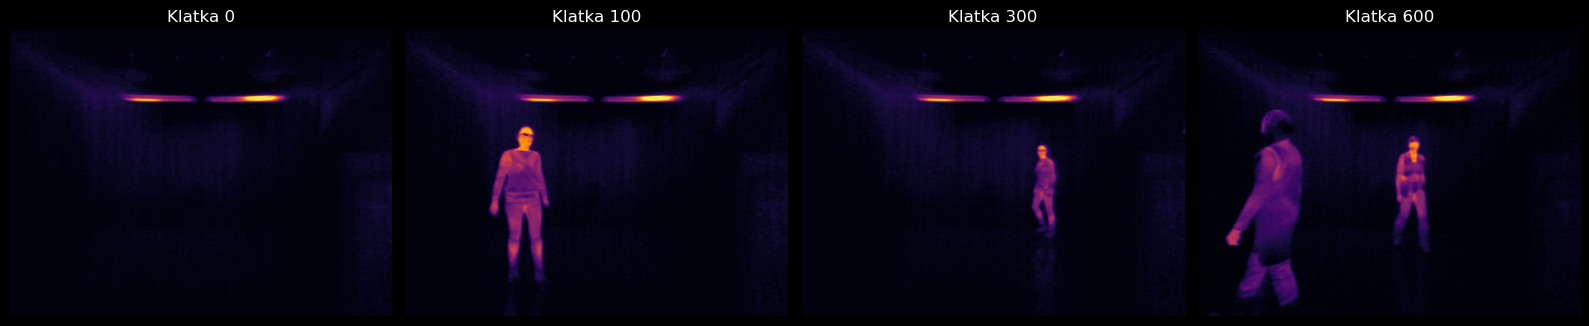

In [60]:
cap = cv2.VideoCapture(VIDEO_PATH)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
print(f"Liczba klatek: {total_frames}, rozmiar: {int(cap.get(3))}x{int(cap.get(4))}")

# Pokaż kilka klatek z różnych momentów
sample_indices = [0, 100, 300, 600]
fig, axes = plt.subplots(1, len(sample_indices), figsize=(16, 4))
for ax, idx in zip(axes, sample_indices):
    cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
    ret, frame = cap.read()
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    ax.imshow(gray, cmap='inferno')
    ax.set_title(f"Klatka {idx}")
    ax.axis('off')
plt.tight_layout()
plt.show()
cap.release()

### Krok 2 – Binaryzacja (progowanie)

Próg Otsu: 60


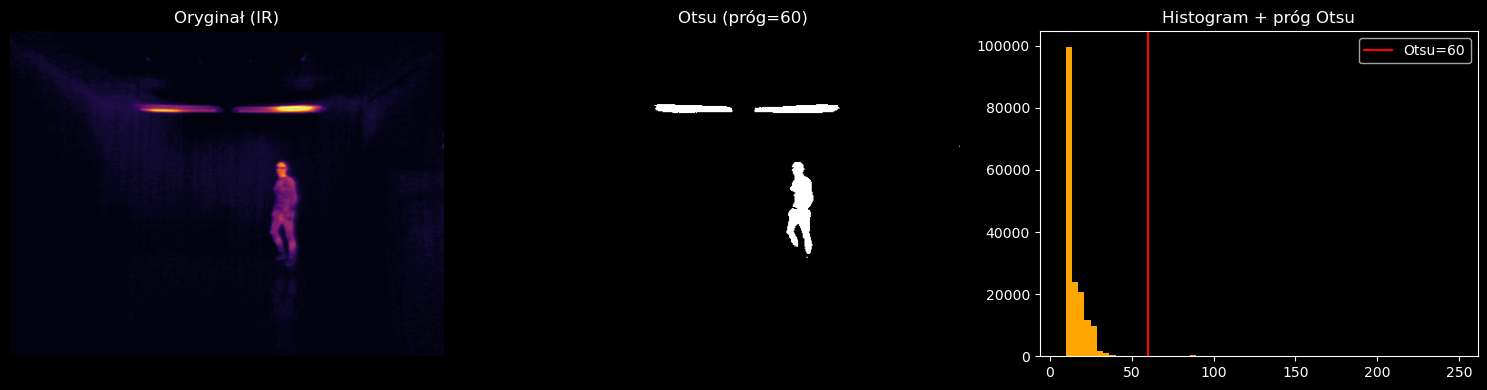

In [61]:
cap = cv2.VideoCapture(VIDEO_PATH)
cap.set(cv2.CAP_PROP_POS_FRAMES, 300)
ret, frame = cap.read()
cap.release()
gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

# Próg Otsu – automatycznie dobiera wartość separującą tło od obiektów
otsu_thresh, binary_otsu = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
print(f"Próg Otsu: {otsu_thresh:.0f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(gray, cmap='inferno'); axes[0].set_title("Oryginał (IR)"); axes[0].axis('off')
axes[1].imshow(binary_otsu, cmap='gray'); axes[1].set_title(f"Otsu (próg={otsu_thresh:.0f})"); axes[1].axis('off')
axes[2].hist(gray.ravel(), bins=64, color='orange'); axes[2].axvline(otsu_thresh, color='red', label=f'Otsu={otsu_thresh:.0f}')
axes[2].set_title("Histogram + próg Otsu"); axes[2].legend()
plt.tight_layout(); plt.show()

binary_filtered_step2 = binary_otsu  # przekazujemy dalej

### Krok 3 – Filtracja morfologiczna

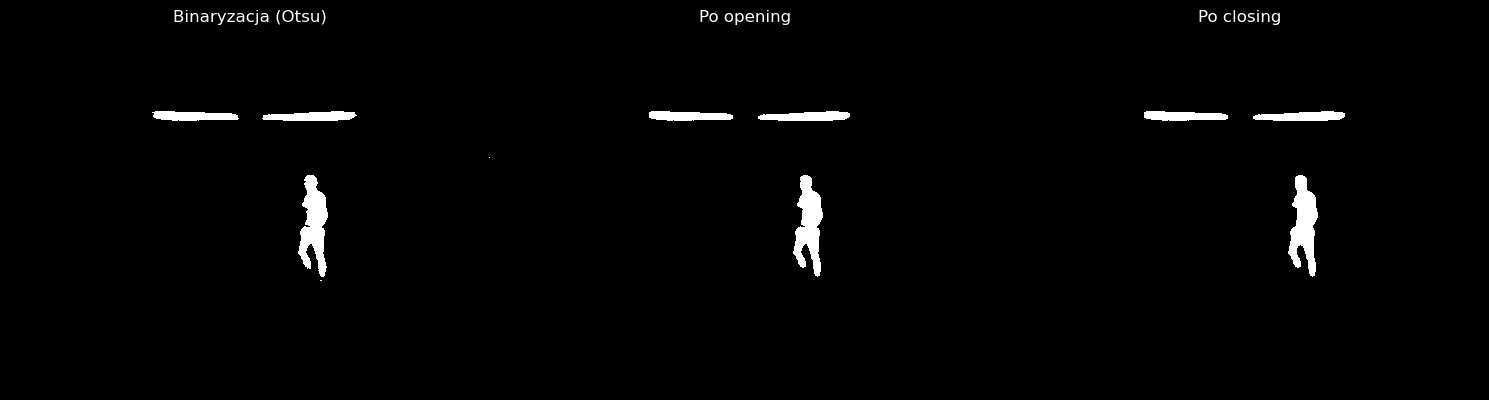

In [62]:
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))

opened  = cv2.morphologyEx(binary_filtered_step2, cv2.MORPH_OPEN,  kernel)
closed  = cv2.morphologyEx(opened,                cv2.MORPH_CLOSE, kernel)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(binary_filtered_step2, cmap='gray'); axes[0].set_title("Binaryzacja (Otsu)"); axes[0].axis('off')
axes[1].imshow(opened,                cmap='gray'); axes[1].set_title("Po opening"); axes[1].axis('off')
axes[2].imshow(closed,                cmap='gray'); axes[2].set_title("Po closing"); axes[2].axis('off')
plt.tight_layout(); plt.show()

binary_filtered = closed

### Krok 4 – Etykietowanie obiektów (connected components)

Znaleziono obiektów (bez tła): 3


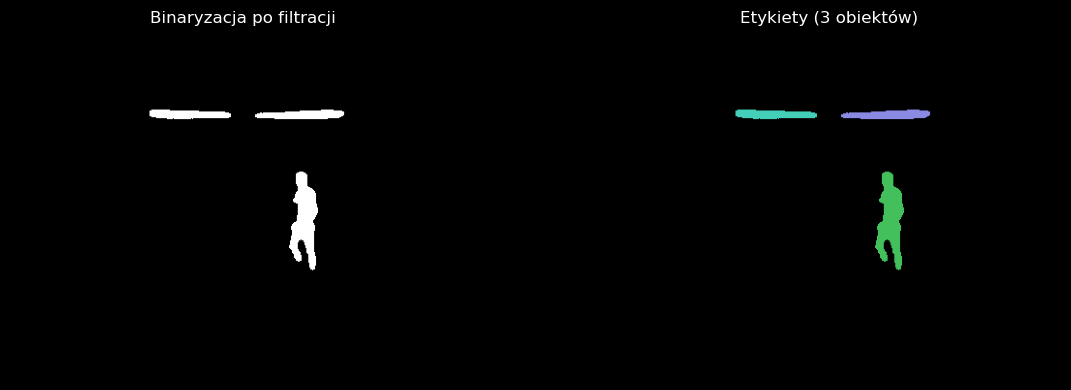

In [63]:
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary_filtered)
print(f"Znaleziono obiektów (bez tła): {num_labels - 1}")

# Kolorowe etykiety do wizualizacji
label_colors = np.zeros((*labels.shape, 3), dtype=np.uint8)
rng = np.random.default_rng(42)
for lbl in range(1, num_labels):
    label_colors[labels == lbl] = rng.integers(50, 255, 3)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(binary_filtered, cmap='gray'); axes[0].set_title("Binaryzacja po filtracji"); axes[0].axis('off')
axes[1].imshow(label_colors);                axes[1].set_title(f"Etykiety ({num_labels-1} obiektów)"); axes[1].axis('off')
plt.tight_layout(); plt.show()

### Krok 5 – Filtrowanie obiektów wg proporcji i rozmiaru

Obiektów po filtracji: 1


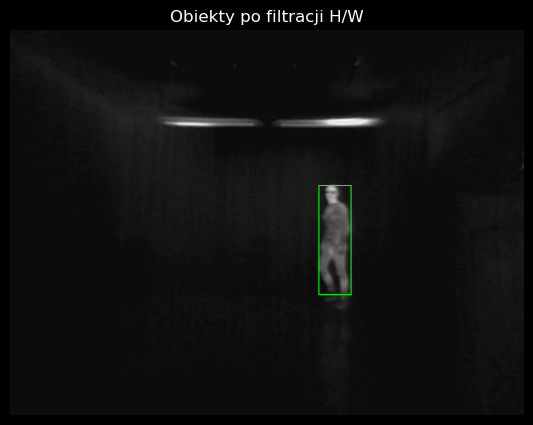

In [64]:
# Parametry filtrowania
MIN_AREA       = 150    # minimalna powierzchnia [px]
MIN_RATIO      = 1.0    # min stosunek H/W (obiekt wyższy niż szeroki)
MAX_RATIO      = 6.0    # max H/W (żeby odrzucić wąskie artefakty)

valid_boxes = []  # (x, y, w, h)
for lbl in range(1, num_labels):
    x, y, w, h, area = stats[lbl]
    if area < MIN_AREA:
        continue
    ratio = h / (w + 1e-6)
    if MIN_RATIO <= ratio <= MAX_RATIO:
        valid_boxes.append((x, y, w, h))

print(f"Obiektów po filtracji: {len(valid_boxes)}")

vis = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
for (x, y, w, h) in valid_boxes:
    cv2.rectangle(vis, (x, y), (x+w, y+h), (0, 255, 0), 1)

plt.figure(figsize=(7, 5))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.title("Obiekty po filtracji H/W")
plt.axis('off'); plt.show()

### Krok 6 – Łączenie fragmentów sylwetki w jeden bounding box

Po scaleniu: 1 prostokątów


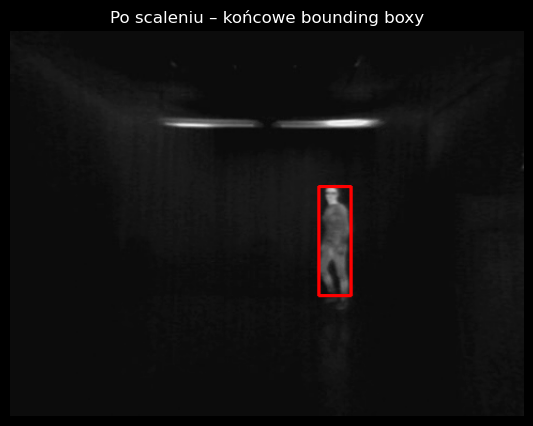

In [65]:
def merge_overlapping_boxes(boxes, gap=20):
    """Łączy ramki, które nachodzą na siebie lub są bliżej niż `gap` pikseli."""
    if not boxes:
        return []
    merged = True
    boxes = list(boxes)
    while merged:
        merged = False
        result = []
        used = [False] * len(boxes)
        for i in range(len(boxes)):
            if used[i]:
                continue
            x1, y1, w1, h1 = boxes[i]
            for j in range(i + 1, len(boxes)):
                if used[j]:
                    continue
                x2, y2, w2, h2 = boxes[j]
                # powiększ ramki o gap i sprawdź przecięcie
                ax1, ay1, ax2, ay2 = x1-gap, y1-gap, x1+w1+gap, y1+h1+gap
                bx1, by1, bx2, by2 = x2,     y2,     x2+w2,     y2+h2
                if ax1 < bx2 and ax2 > bx1 and ay1 < by2 and ay2 > by1:
                    # scal w jeden prostokąt otaczający
                    nx = min(x1, x2); ny = min(y1, y2)
                    nw = max(x1+w1, x2+w2) - nx
                    nh = max(y1+h1, y2+h2) - ny
                    boxes[i] = (nx, ny, nw, nh)
                    x1, y1, w1, h1 = boxes[i]
                    used[j] = True
                    merged = True
            result.append(boxes[i])
        boxes = result
    return boxes

merged_boxes = merge_overlapping_boxes(valid_boxes, gap=30)
print(f"Po scaleniu: {len(merged_boxes)} prostokątów")

vis2 = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
for (x, y, w, h) in merged_boxes:
    cv2.rectangle(vis2, (x, y), (x+w, y+h), (0, 0, 255), 2)

plt.figure(figsize=(7, 5))
plt.imshow(cv2.cvtColor(vis2, cv2.COLOR_BGR2RGB))
plt.title("Po scaleniu – końcowe bounding boxy")
plt.axis('off'); plt.show()

### Krok 7 – Pełny pipeline na wielu klatkach (wizualizacja wyników)

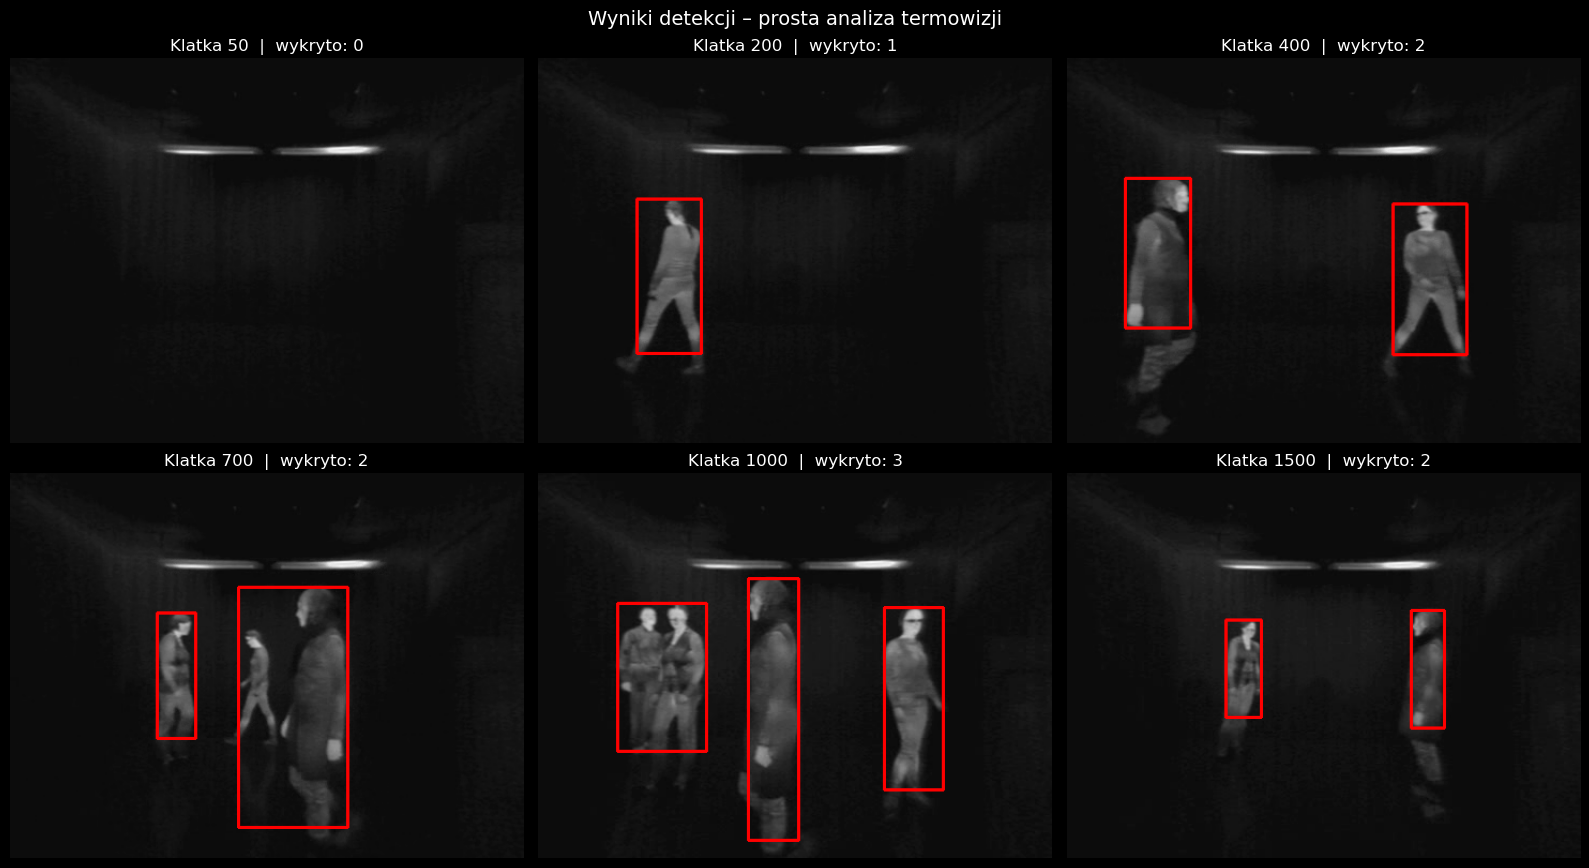

In [66]:
def detect_people(gray, min_area=150, min_ratio=1.0, max_ratio=6.0, gap=30):
    """Zwraca listę bounding boxów (x, y, w, h) wykrytych sylwetek."""
    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN,  kernel)
    binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)
    n, _, stats, _ = cv2.connectedComponentsWithStats(binary)
    boxes = []
    for lbl in range(1, n):
        x, y, w, h, area = stats[lbl]
        if area >= min_area and min_ratio <= h / (w + 1e-6) <= max_ratio:
            boxes.append((x, y, w, h))
    return merge_overlapping_boxes(boxes, gap=gap)

cap = cv2.VideoCapture(VIDEO_PATH)
sample_frames = [50, 200, 400, 700, 1000, 1500]
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, idx in zip(axes.flat, sample_frames):
    cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
    ret, frame = cap.read()
    gray_f = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    boxes = detect_people(gray_f)
    vis = cv2.cvtColor(gray_f, cv2.COLOR_GRAY2BGR)
    for (x, y, w, h) in boxes:
        cv2.rectangle(vis, (x, y), (x+w, y+h), (0, 0, 255), 2)
    ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    ax.set_title(f"Klatka {idx}  |  wykryto: {len(boxes)}")
    ax.axis('off')

cap.release()
plt.suptitle("Wyniki detekcji – prosta analiza termowizji", fontsize=14)
plt.tight_layout(); plt.show()

---
## 12.2 Detekcja YOLOv3 – fuzja wczesna i późna (RGB + termowizja)

Wymagane pliki z platformy UPeL:
- `test_rgb/` – zdjęcia RGB
- `test_thermal/` – odpowiadające obrazy termowizyjne (skala szarości)
- pliki wag i konfiguracji YOLOv3 (early/late fusion)

In [67]:
import os, glob
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ── Ścieżki (TODO0) ──────────────────────────────────────────────────
BASE          = "neural_network"
TEST_RGB      = os.path.join(BASE, "test_rgb")
TEST_THERMAL  = os.path.join(BASE, "test_thermal")

FUSION = "EARLY"   # "EARLY" lub "LATE"

# Pliki wag i konfiguracji
CFG_F     = os.path.join(BASE, "yolov3_testing_f.cfg")
WEIGHTS_F = os.path.join(BASE, "yolov3_training_last_f.weights")  # early fusion

CFG_T     = os.path.join(BASE, "yolov3_testing_t.cfg")
WEIGHTS_T = os.path.join(BASE, "yolov3_training_last_t.weights")  # thermal (late)

CFG_C     = os.path.join(BASE, "yolov3_testing_c.cfg")
WEIGHTS_C = os.path.join(BASE, "yolov3_training_last_c.weights")  # RGB/color (late)

rgb_files = sorted(glob.glob(os.path.join(TEST_RGB, "img*.png")),
                   key=lambda p: int(os.path.splitext(os.path.basename(p))[0][3:]))
print(f"Obrazów RGB: {len(rgb_files)},  przykład: {rgb_files[0]}")

Obrazów RGB: 519,  przykład: neural_network/test_rgb/img0.png


In [68]:
def detect(net, img):
    """Uruchamia sieć YOLO i zwraca listę ramek [x, y, w, h] (conf > 0.3)."""
    h, w = img.shape[:2]
    blob = cv2.dnn.blobFromImage(img, 1/255, (416, 416), (0, 0, 0), swapRB=True, crop=False)
    net.setInput(blob)
    outputs = net.forward(net.getUnconnectedOutLayersNames())
    boxes = []
    for out in outputs:
        for det in out:
            conf = det[5:].max()
            if conf > 0.3:
                cx, cy = int(det[0]*w), int(det[1]*h)
                bw, bh = int(det[2]*w), int(det[3]*h)
                boxes.append([cx - bw//2, cy - bh//2, bw, bh])
    return boxes

def filter_boxes(boxes):
    """Scala ramki z blisko leżącymi środkami (duplikaty z wielu warstw YOLO)."""
    all_paired = []
    for ii, (x1,y1,w1,h1) in enumerate(boxes):
        cx1, cy1 = x1 + w1//2, y1 + h1//2
        group = [ii]
        for jj, (x2,y2,w2,h2) in enumerate(boxes):
            if jj != ii:
                cx2, cy2 = x2 + w2//2, y2 + h2//2
                if abs(cx2-cx1) < 10 and abs(cy2-cy1) < 10:
                    group.append(jj)
        all_paired.append(group)
    all_paired.sort(key=lambda g: len(g), reverse=True)
    used, final = [], []
    for group in all_paired:
        if all(i not in used for i in group):
            used += group
            final.append(group)
    return [[int(sum(boxes[i][a] for i in g)/len(g)) for a in range(4)] for g in final]

def IoU(rect1, rect2):
    """Intersection over Union dla (x, y, w, h)."""
    x1,y1,w1,h1 = rect1; x2,y2,w2,h2 = rect2
    left, right = max(x1,x2), min(x1+w1,x2+w2)
    top,  bot   = max(y1,y2), min(y1+h1,y2+h2)
    inter = max(right-left, 0) * max(bot-top, 0)
    if inter == 0:
        return 0.0
    return inter / (w1*h1 + w2*h2 - inter)

### TODO1 – Wczesna fuzja (Early Fusion): kanał R = max(R, thermal)

Sieć early-fusion załadowana


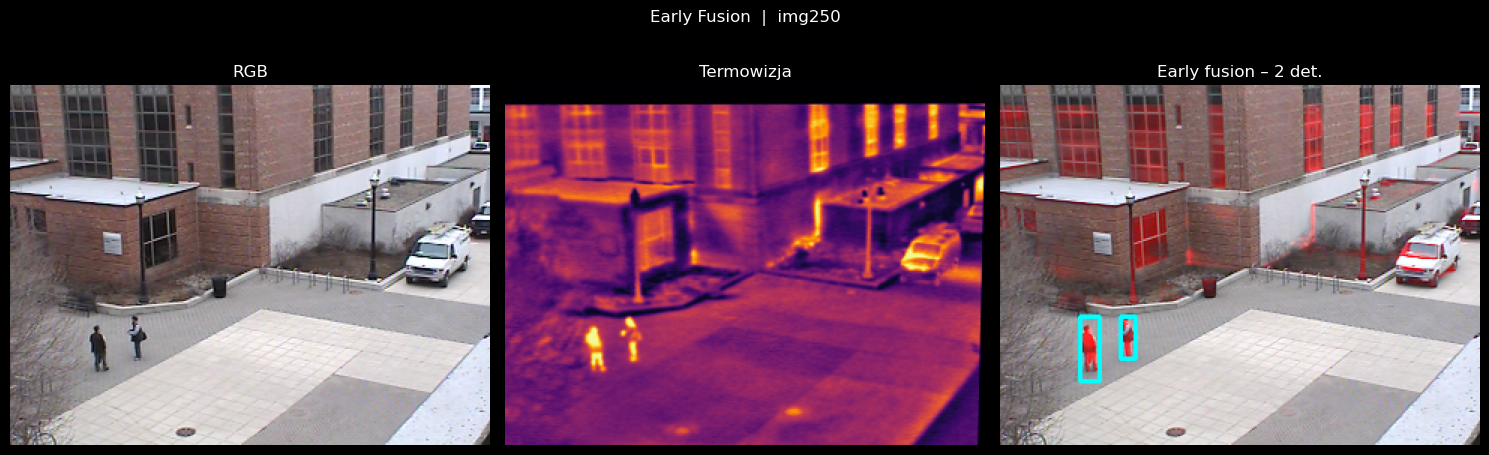

In [ ]:
if FUSION == "EARLY":
    net_fus = cv2.dnn.readNet(WEIGHTS_F, CFG_F)
    print("Sieć early-fusion załadowana")

# Wczytaj przykładowy obraz
idx = 250
img_rgb     = cv2.imread(os.path.join(TEST_RGB,     f"img{idx}.png"))
img_thermal = cv2.imread(os.path.join(TEST_THERMAL, f"img{idx}.png"))
img_thermal = cv2.cvtColor(img_thermal, cv2.COLOR_BGR2GRAY)

if FUSION == "EARLY":
    new_fus = np.zeros_like(img_rgb)
    new_fus[:, :, :2] = img_rgb[:, :, :2]                        # kanały B i G bez zmian
    new_fus[:, :,  2] = np.maximum(img_rgb[:, :, 2], img_thermal)  # R = max(R, thermal)
    new_fus = new_fus.astype("uint8")

    boxes     = detect(net_fus, new_fus)
    out_boxes = filter_boxes(boxes)
    out_img   = new_fus.copy()
    for x,y,w,h in out_boxes:
        cv2.rectangle(out_img, (x,y), (x+w,y+h), (255,255,0), 2)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(cv2.cvtColor(img_rgb,  cv2.COLOR_BGR2RGB));  axes[0].set_title("RGB"); axes[0].axis('off')
    axes[1].imshow(img_thermal, cmap='inferno');                 axes[1].set_title("Termowizja"); axes[1].axis('off')
    axes[2].imshow(cv2.cvtColor(out_img, cv2.COLOR_BGR2RGB));   axes[2].set_title(f"Early fusion – {len(out_boxes)} det."); axes[2].axis('off')
    plt.suptitle(f"Early Fusion  |  img{idx}"); plt.tight_layout(); plt.show()

### TODO2 – Późna fuzja (Late Fusion): IoU + dopasowanie ramek

### Późna fuzja – uruchomienie z prawdziwymi obrazami

Sieci late-fusion załadowane


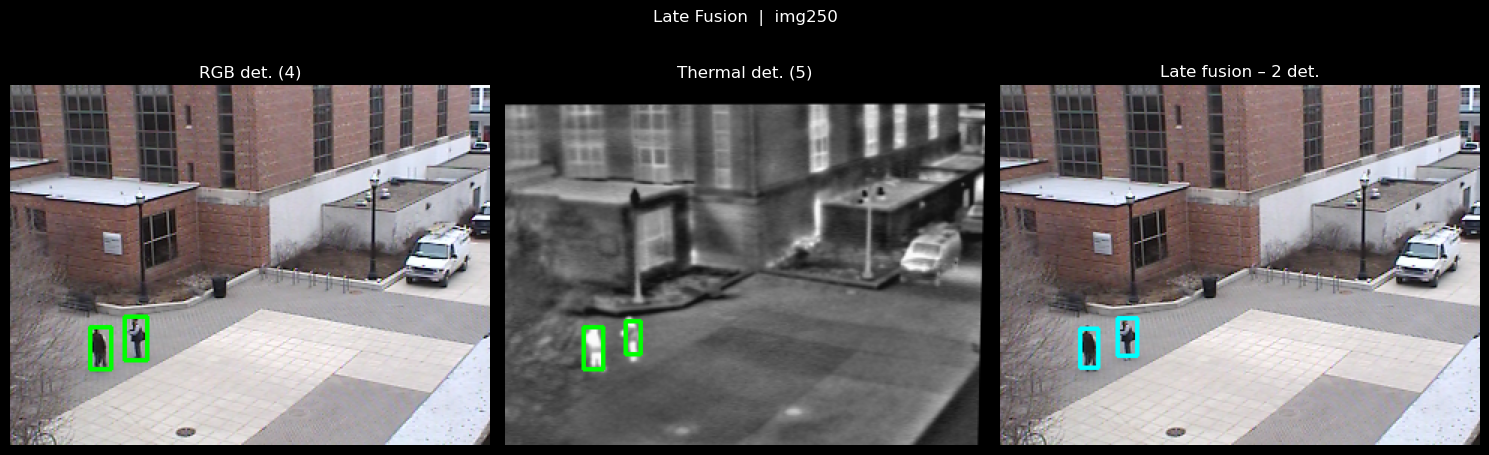

In [73]:
FUSION = "LATE"
if FUSION == "LATE":
    net_therm = cv2.dnn.readNet(WEIGHTS_T, CFG_T)
    net_rgb   = cv2.dnn.readNet(WEIGHTS_C, CFG_C)
    print("Sieci late-fusion załadowane")

    Rect1 = detect(net_therm, img_thermal)   # ramki z detektora termowizyjnego
    Rect2 = detect(net_rgb,   img_rgb)        # ramki z detektora RGB

    # TODO2 – dopasowanie ramek przez IoU i uśrednienie
    # Krok 1: wszystkie pary z IoU > 0
    boxes_iou = []
    for i, r1 in enumerate(Rect1):
        for j, r2 in enumerate(Rect2):
            iou_val = IoU(r1, r2)
            if iou_val > 0:
                boxes_iou.append([(i, j), iou_val])

    # Krok 2: sortuj malejąco po IoU
    boxes_iou = sorted(boxes_iou, key=lambda a: a[1], reverse=True)

    # Krok 3-4: zachłanne parowanie – każda ramka co najwyżej raz
    Rect1_paired, Rect2_paired, paired_boxes = [], [], []
    for elem in boxes_iou:
        (i, j), iou_val = elem
        if i not in Rect1_paired and j not in Rect2_paired:
            paired_boxes.append((i, j))
            Rect1_paired.append(i)
            Rect2_paired.append(j)

    # Krok 5: uśrednianie współrzędnych sparowanych ramek
    boxes = []
    for i, j in paired_boxes:
        r1, r2 = Rect1[i], Rect2[j]
        avg_r = [int((r1[k] + r2[k]) / 2) for k in range(4)]
        boxes.append(avg_r)

    out_boxes = filter_boxes(boxes)
    out_img   = img_rgb.copy()
    for x,y,w,h in out_boxes:
        cv2.rectangle(out_img, (x,y), (x+w,y+h), (255,255,0), 2)

    # Wizualizacja: RGB det. | Thermal det. | Late fusion
    vis_rgb   = img_rgb.copy()
    vis_therm = cv2.cvtColor(img_thermal, cv2.COLOR_GRAY2BGR)
    for x,y,w,h in filter_boxes(Rect2): cv2.rectangle(vis_rgb,   (x,y),(x+w,y+h),(0,255,0),2)
    for x,y,w,h in filter_boxes(Rect1): cv2.rectangle(vis_therm, (x,y),(x+w,y+h),(0,255,0),2)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(cv2.cvtColor(vis_rgb,   cv2.COLOR_BGR2RGB)); axes[0].set_title(f"RGB det. ({len(Rect2)})"); axes[0].axis('off')
    axes[1].imshow(cv2.cvtColor(vis_therm, cv2.COLOR_BGR2RGB)); axes[1].set_title(f"Thermal det. ({len(Rect1)})"); axes[1].axis('off')
    axes[2].imshow(cv2.cvtColor(out_img,   cv2.COLOR_BGR2RGB)); axes[2].set_title(f"Late fusion – {len(out_boxes)} det."); axes[2].axis('off')
    plt.suptitle(f"Late Fusion  |  img{idx}"); plt.tight_layout(); plt.show()

### Porównanie Early vs Late fusion na kilku klatkach

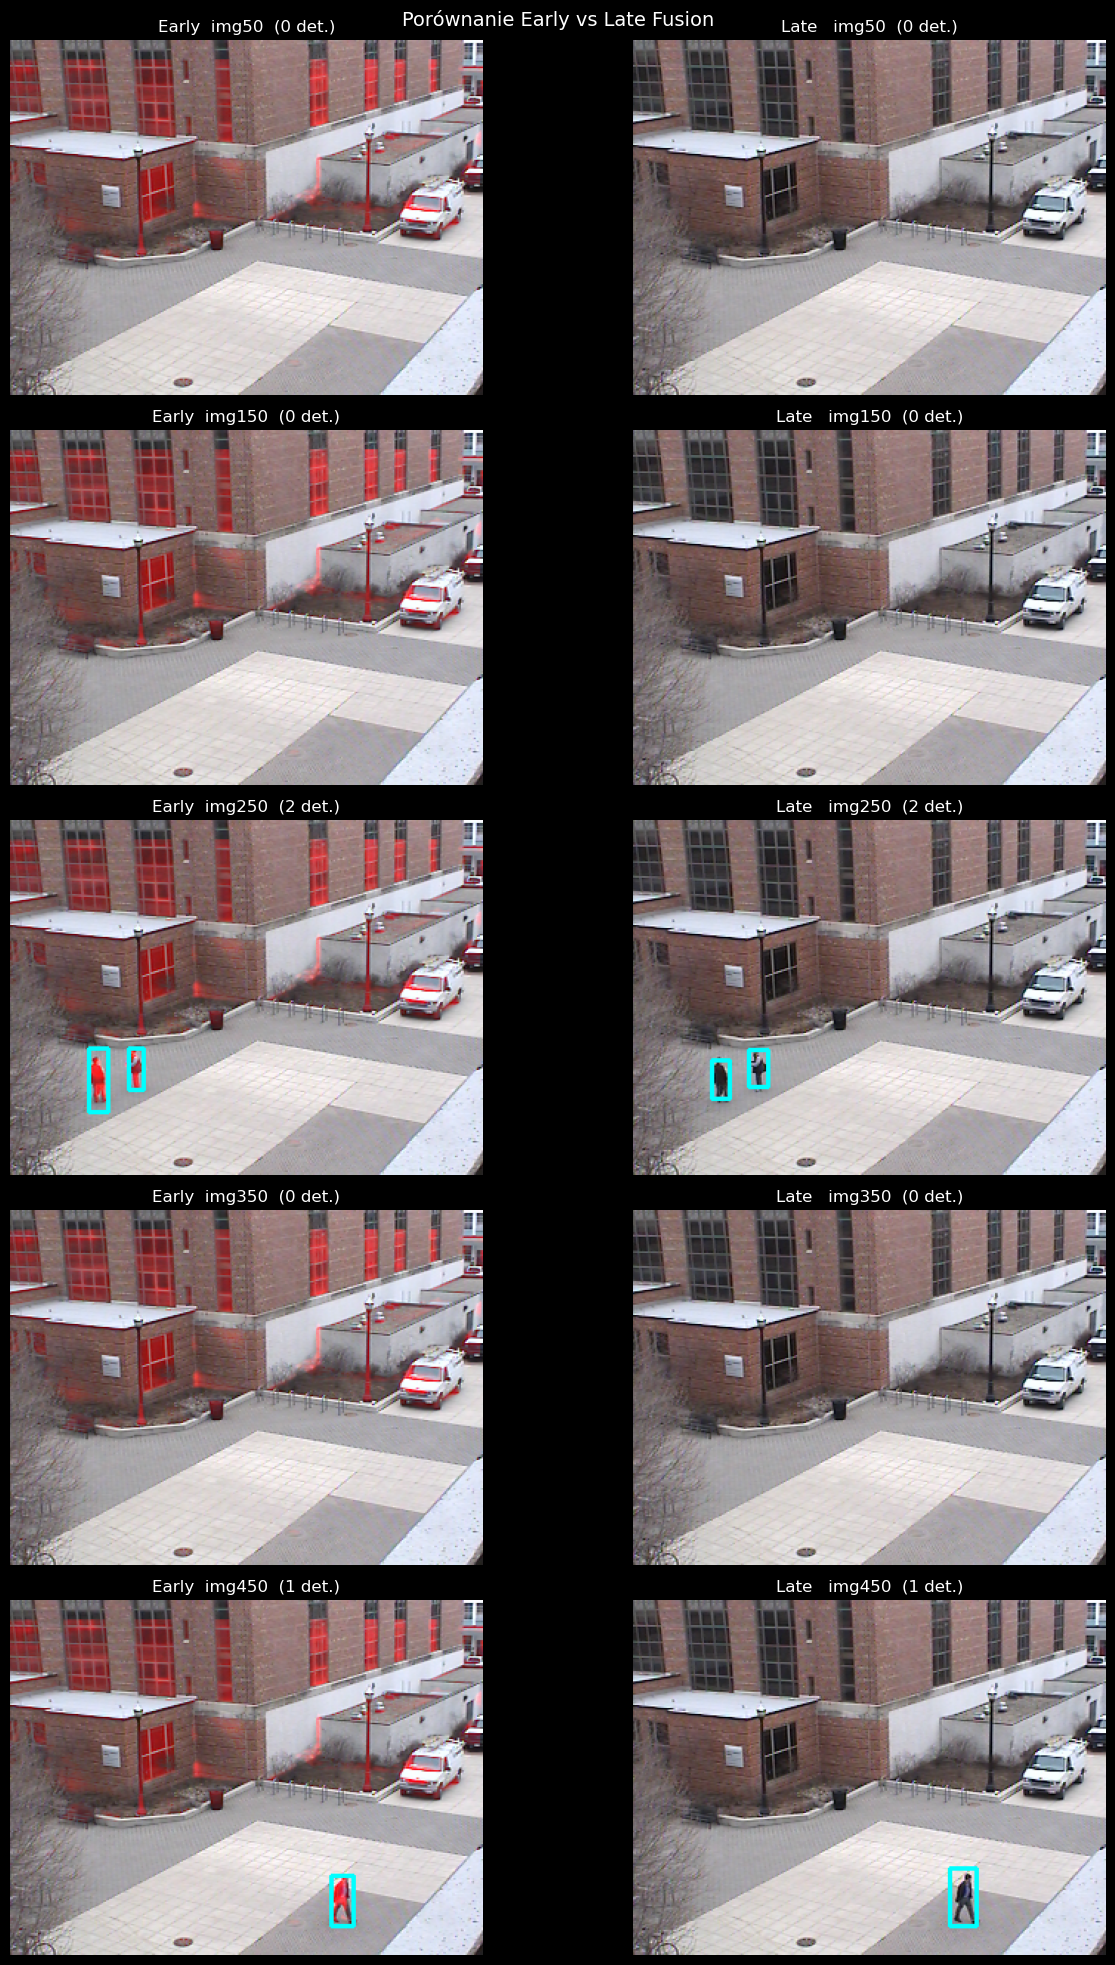

In [72]:
# Załaduj obie sieci (jeśli jeszcze nie załadowane)
if 'net_fus' not in dir():
    net_fus   = cv2.dnn.readNet(WEIGHTS_F, CFG_F)
if 'net_therm' not in dir():
    net_therm = cv2.dnn.readNet(WEIGHTS_T, CFG_T)
if 'net_rgb_late' not in dir():
    net_rgb_late = cv2.dnn.readNet(WEIGHTS_C, CFG_C)

sample_ids = [50, 150, 250, 350, 450]
fig, axes = plt.subplots(len(sample_ids), 2, figsize=(14, 4*len(sample_ids)))

for row, i in enumerate(sample_ids):
    rgb   = cv2.imread(os.path.join(TEST_RGB,     f"img{i}.png"))
    therm = cv2.imread(os.path.join(TEST_THERMAL, f"img{i}.png"))
    therm = cv2.cvtColor(therm, cv2.COLOR_BGR2GRAY)

    # Early fusion
    nf = np.zeros_like(rgb)
    nf[:,:,:2] = rgb[:,:,:2]
    nf[:,:,2]  = np.maximum(rgb[:,:,2], therm)
    nf = nf.astype("uint8")
    early_boxes = filter_boxes(detect(net_fus, nf))
    vis_e = nf.copy()
    for x,y,w,h in early_boxes: cv2.rectangle(vis_e,(x,y),(x+w,y+h),(255,255,0),2)

    # Late fusion
    R1 = detect(net_therm, therm)
    R2 = detect(net_rgb_late, rgb)
    pairs_iou = sorted(
        [[(ii,jj), IoU(r1,r2)] for ii,r1 in enumerate(R1) for jj,r2 in enumerate(R2) if IoU(r1,r2)>0],
        key=lambda a: a[1], reverse=True)
    u1,u2,late_boxes = [],[],[]
    for (ii,jj),_ in pairs_iou:
        if ii not in u1 and jj not in u2:
            u1.append(ii); u2.append(jj)
            late_boxes.append([int((R1[ii][k]+R2[jj][k])/2) for k in range(4)])
    late_boxes = filter_boxes(late_boxes)
    vis_l = rgb.copy()
    for x,y,w,h in late_boxes: cv2.rectangle(vis_l,(x,y),(x+w,y+h),(255,255,0),2)

    axes[row,0].imshow(cv2.cvtColor(vis_e, cv2.COLOR_BGR2RGB))
    axes[row,0].set_title(f"Early  img{i}  ({len(early_boxes)} det.)"); axes[row,0].axis('off')
    axes[row,1].imshow(cv2.cvtColor(vis_l, cv2.COLOR_BGR2RGB))
    axes[row,1].set_title(f"Late   img{i}  ({len(late_boxes)} det.)"); axes[row,1].axis('off')

plt.suptitle("Porównanie Early vs Late Fusion", fontsize=14)
plt.tight_layout(); plt.show()